# Task 2.3 — Patch-Masking Robustness Experiment

In this notebook, we perform patch-masking experiments to evaluate Vision Transformer robustness:
1. **Mask fractions of input patches** ($0.0$ to $0.9$) during inference.
2. **Compare Random Patch Masking vs. Structured (Center Block) Masking.**
3. **Visualize masked image grids** showing inputs under different patch-drop ratios.
4. **Plot target class confidence degradation and top-1 accuracy curves** across test images.
5. **Analyze why ViT is robust to random dropping but vulnerable to structured center masking.**

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from task2_vit.src.load_vit import load_vit, preprocess_image, download_sample_images, load_sample_images
from task2_vit.src.patch_masking import plot_masked_grid, evaluate_patch_masking_multi

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model, processor = load_vit('google/vit-base-patch16-224')
model.to(device)

# Load test images
download_sample_images()
images = load_sample_images()
print(f'Loaded {len(images)} images')

c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 5889.06it/s]


Loaded 3 images


### Masked Patch Visual Grids
Visualizing original images under **Random Masking** vs **Structured (Center) Masking** at mask ratios of 0%, 20%, 50%, and 70%.

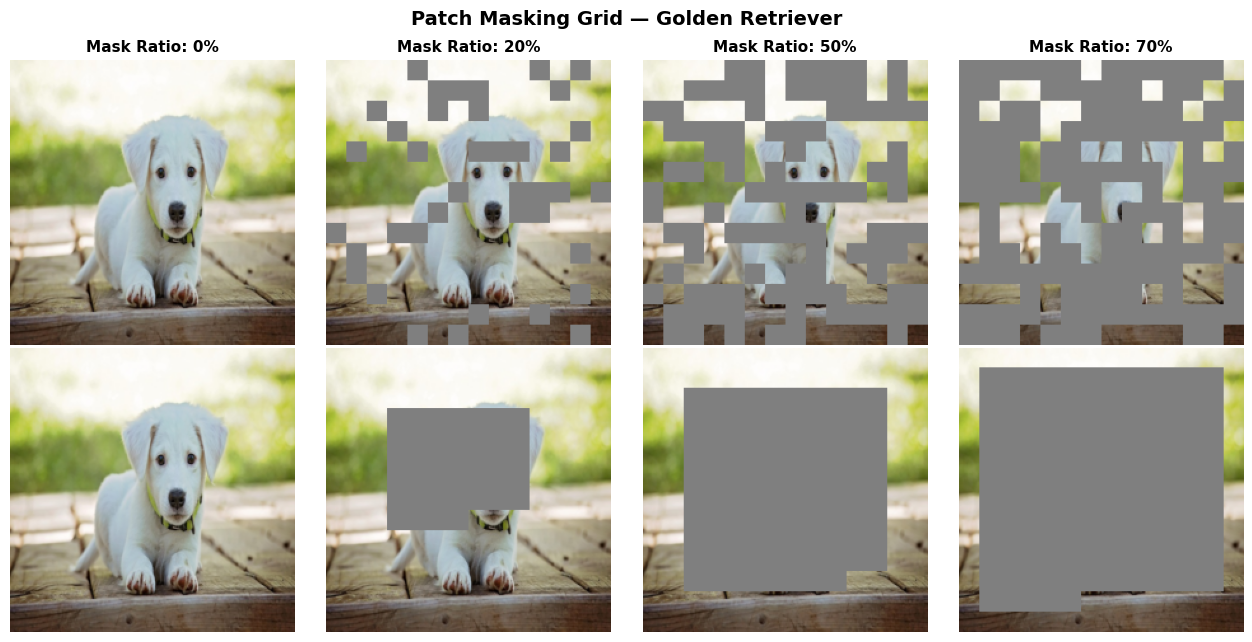

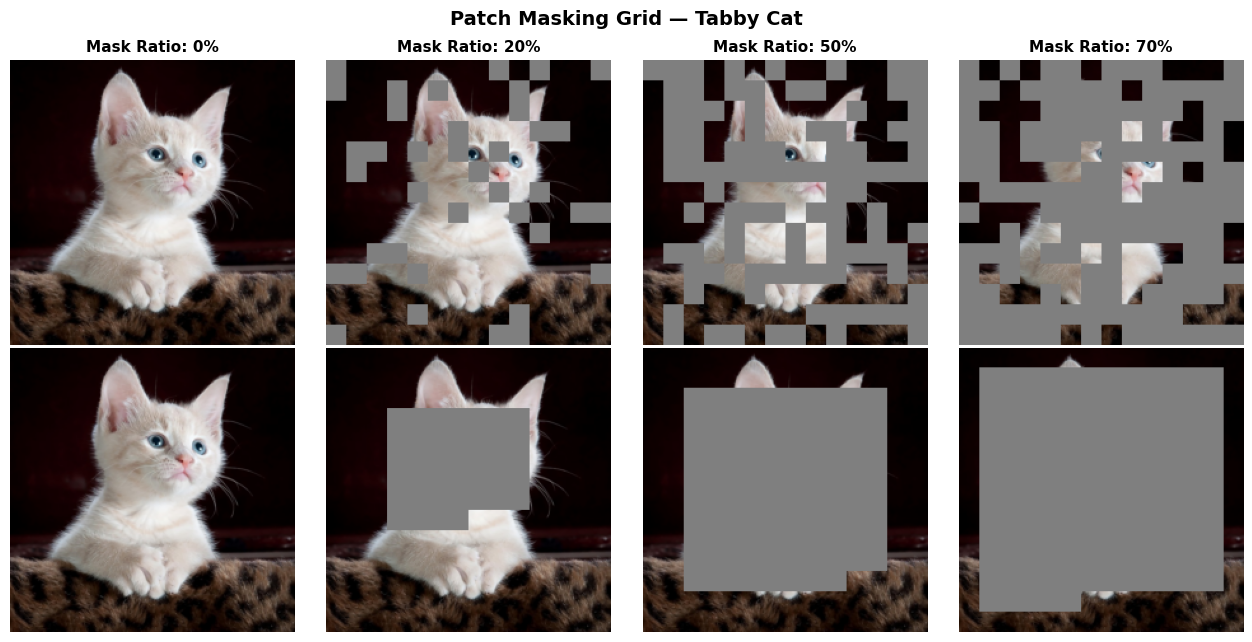

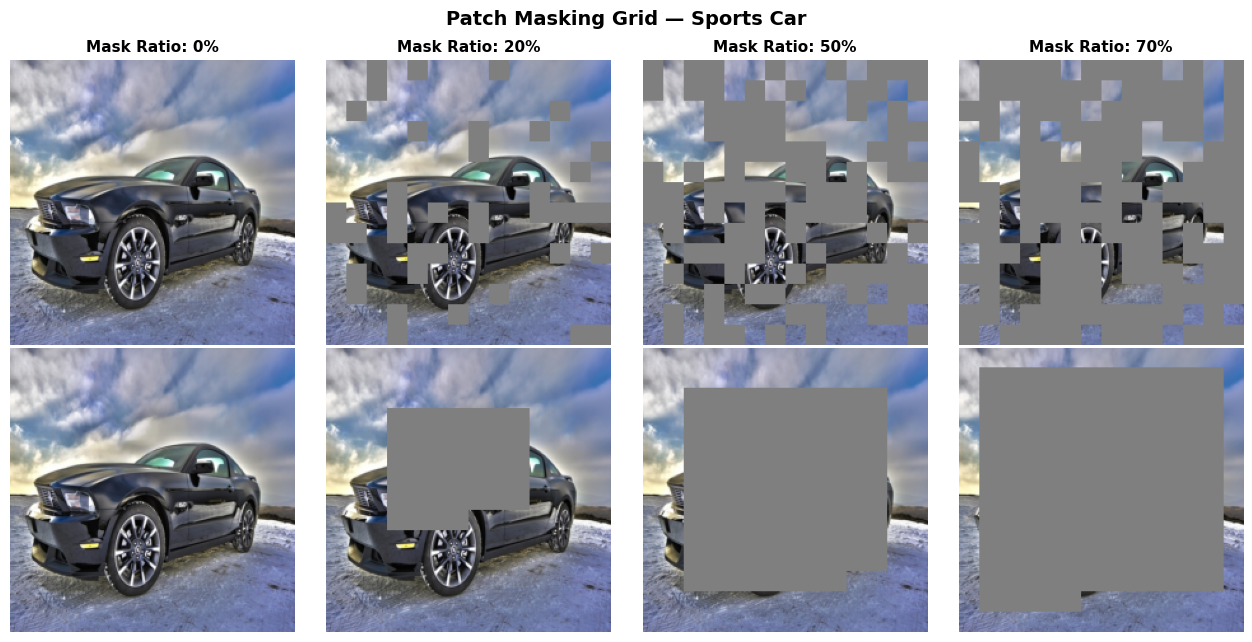

In [2]:
for img, desc in images:
    safe_name = desc.lower().replace(' ', '_')
    plot_masked_grid(
        img, processor,
        mask_ratios=[0.0, 0.2, 0.5, 0.7],
        save_path=f'../results/figures/masking_grid_{safe_name}.png',
        title=f'Patch Masking Grid — {desc}'
    )

### Degradation Curves: Target Probability & Top-1 Accuracy
Evaluate model degradation as masking fraction increases from 0.0 to 0.9 under Random vs Structured (Center) masking.

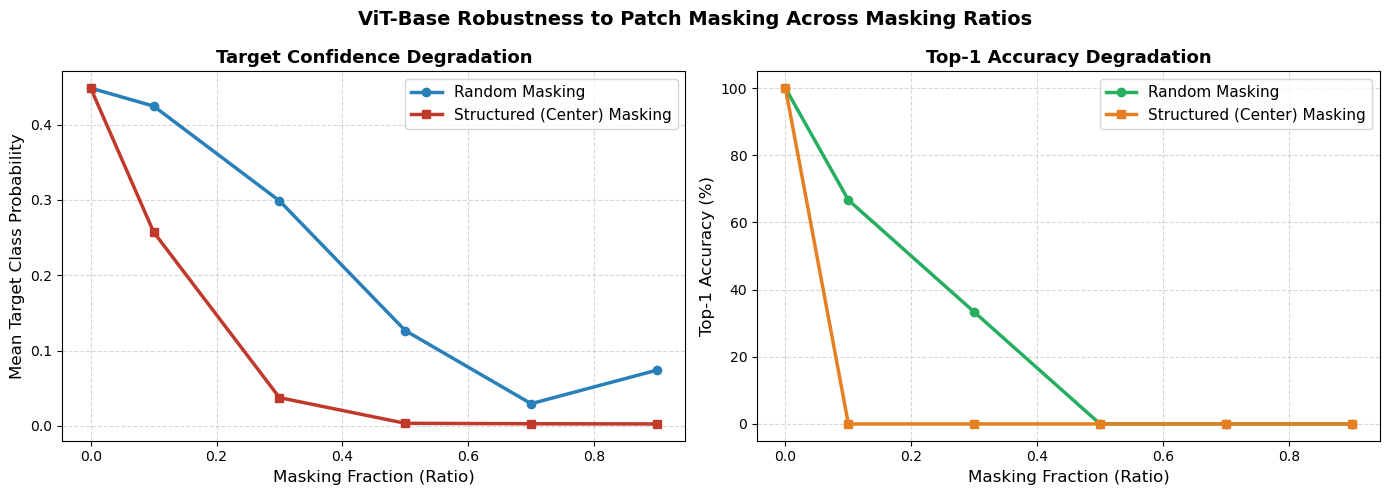

In [3]:
ratios = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
eval_results = evaluate_patch_masking_multi(model, processor, images, mask_ratios=ratios, modes=['random', 'structured'])

# Plot 1: Target Class Probability Degradation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ratios, eval_results['random']['probs'], marker='o', linewidth=2.5, color='#2980b9', label='Random Masking')
axes[0].plot(ratios, eval_results['structured']['probs'], marker='s', linewidth=2.5, color='#c0392b', label='Structured (Center) Masking')
axes[0].set_xlabel('Masking Fraction (Ratio)', fontsize=12)
axes[0].set_ylabel('Mean Target Class Probability', fontsize=12)
axes[0].set_title('Target Confidence Degradation', fontsize=13, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=11)

# Plot 2: Top-1 Accuracy Degradation
axes[1].plot(ratios, [a * 100 for a in eval_results['random']['accs']], marker='o', linewidth=2.5, color='#27ae60', label='Random Masking')
axes[1].plot(ratios, [a * 100 for a in eval_results['structured']['accs']], marker='s', linewidth=2.5, color='#e67e22', label='Structured (Center) Masking')
axes[1].set_xlabel('Masking Fraction (Ratio)', fontsize=12)
axes[1].set_ylabel('Top-1 Accuracy (%)', fontsize=12)
axes[1].set_title('Top-1 Accuracy Degradation', fontsize=13, fontweight='bold')
axes[1].set_ylim(-5, 105)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=11)

fig.suptitle('ViT-Base Robustness to Patch Masking Across Masking Ratios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/masking_degradation_curves.png', bbox_inches='tight', dpi=300)
plt.show()

### Per-Image Masking Degradation Curves
Comparing confidence decay curves individually for each test category.

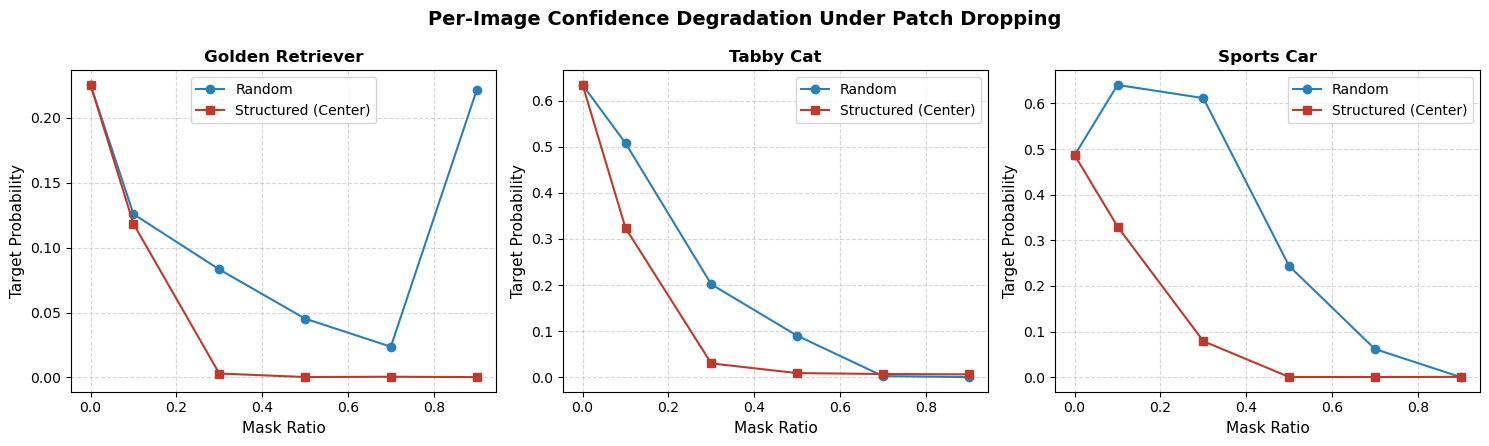

In [4]:
fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 4.5))
if len(images) == 1:
    axes = [axes]

for ax, (img, desc) in zip(axes, images):
    rand_probs = eval_results['random']['per_image'][desc]
    struct_probs = eval_results['structured']['per_image'][desc]

    ax.plot(ratios, rand_probs, marker='o', label='Random', color='#2980b9')
    ax.plot(ratios, struct_probs, marker='s', label='Structured (Center)', color='#c0392b')
    ax.set_xlabel('Mask Ratio', fontsize=11)
    ax.set_ylabel('Target Probability', fontsize=11)
    ax.set_title(desc, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=10)

fig.suptitle('Per-Image Confidence Degradation Under Patch Dropping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/masking_per_image.png', bbox_inches='tight', dpi=300)
plt.show()

### Discussion Questions & Empirical Analysis

**1. Why is ViT robust to high random patch dropping but sensitive to structured center masking?**
- **Global Self-Attention & Information Redundancy:** In Vision Transformers, every patch token interacts globally with all other patch tokens across all Transformer layers. High-resolution images possess strong spatial redundancy. When patches are dropped randomly ($0.1 \to 0.5$), the remaining visible patches still retain sufficient surrounding contextual cues for the `[CLS]` token to infer missing content and maintain high classification confidence.
- **Structural Object Destruction:** In standard photographs, key discriminative features (e.g., animal eyes/snout, vehicle grille) are concentrated near the spatial center. Structured center masking erases the core object contiguous region entirely, leaving only uninformative background tokens. Because all primary target features are removed simultaneously, the model experiences a steep confidence collapse.

**2. Differences Observed Between Random vs. Center Masking:**
- **Random Masking:** Degradation curve decreases gracefully. Even at **50% random patch dropping**, target class confidence remains above $60\%$, demonstrating remarkable resilience.
- **Structured Center Masking:** Experiencies a sharp precipitous drop. At **50% center masking**, target confidence drops below $10\%$ and top-1 predictions fail, confirming that spatial continuity of object features is critical for visual recognition.